# Summary Statistics

In [1]:
import pandas as pd
fileName = 'benin-malanville.csv'
# Load the data
df = pd.read_csv(f'../data/raw/{fileName}')

In [2]:
df.head()

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
0,2021-08-09 00:01,-1.2,-0.2,-1.1,0.0,0.0,26.2,93.4,0.0,0.4,0.1,122.1,0.0,998,0,0.0,26.3,26.2,NaN
1,2021-08-09 00:02,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.6,0.0,0.0,0.0,0.0,0.0,998,0,0.0,26.3,26.2,NaN
2,2021-08-09 00:03,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.7,0.3,1.1,0.5,124.6,1.5,997,0,0.0,26.4,26.2,NaN
3,2021-08-09 00:04,-1.1,-0.1,-1.0,0.0,0.0,26.2,93.3,0.2,0.7,0.4,120.3,1.3,997,0,0.0,26.4,26.3,NaN
4,2021-08-09 00:05,-1.0,-0.1,-1.0,0.0,0.0,26.2,93.3,0.1,0.7,0.3,113.2,1.0,997,0,0.0,26.4,26.3,NaN


<!-- # Data Quality Check -->

In [3]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525600 entries, 0 to 525599
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Timestamp      525600 non-null  object 
 1   GHI            525600 non-null  float64
 2   DNI            525600 non-null  float64
 3   DHI            525600 non-null  float64
 4   ModA           525600 non-null  float64
 5   ModB           525600 non-null  float64
 6   Tamb           525600 non-null  float64
 7   RH             525600 non-null  float64
 8   WS             525600 non-null  float64
 9   WSgust         525600 non-null  float64
 10  WSstdev        525600 non-null  float64
 11  WD             525600 non-null  float64
 12  WDstdev        525600 non-null  float64
 13  BP             525600 non-null  int64  
 14  Cleaning       525600 non-null  int64  
 15  Precipitation  525600 non-null  float64
 16  TModA          525600 non-null  float64
 17  TModB          525600 non-nul

In [4]:
df.describe()

,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
mean,240.559452,167.187516,115.358961,236.589496,228.883576,28.179683,54.487969,2.121113,2.809195,0.473390,153.435172,8.582407,994.197199,0.000923,0.001905,35.246026,32.471736,NaN
std,331.131327,261.710501,158.691074,326.894859,316.536515,5.924297,28.073069,1.603466,2.029120,0.273395,102.332842,6.385864,2.474993,0.030363,0.037115,14.807258,12.348743,NaN
min,-12.900000,-7.800000,-12.600000,0.000000,0.000000,11.000000,2.100000,0.000000,0.000000,0.000000,0.000000,0.000000,985.000000,0.000000,0.000000,9.000000,8.100000,NaN
25%,-2.000000,-0.500000,-2.100000,0.000000,0.000000,24.200000,28.800000,1.000000,1.300000,0.400000,59.000000,3.700000,993.000000,0.000000,0.000000,24.200000,23.600000,NaN
50%,1.800000,-0.100000,1.600000,4.500000,4.300000,28.000000,55.100000,1.900000,2.600000,0.500000,181.000000,8.600000,994.000000,0.000000,0.000000,30.000000,28.900000,NaN
75%,483.400000,314.200000,216.300000,463.700000,447.900000,32.300000,80.100000,3.100000,4.100000,0.600000,235.100000,12.300000,996.000000,0.000000,0.000000,46.900000,41.500000,NaN
max,1413.000000,952.300000,759.200000,1342.300000,1342.300000,43.800000,100.000000,19.500000,26.600000,4.200000,360.000000,99.400000,1003.000000,1.000000,2.500000,81.000000,72.500000,NaN


In [5]:
missing_data = df.isnull().sum()
print(missing_data)

Timestamp             0
GHI                   0
DNI                   0
DHI                   0
ModA                  0
ModB                  0
Tamb                  0
RH                    0
WS                    0
WSgust                0
WSstdev               0
WD                    0
WDstdev               0
BP                    0
Cleaning              0
Precipitation         0
TModA                 0
TModB                 0
Comments         525600
dtype: int64


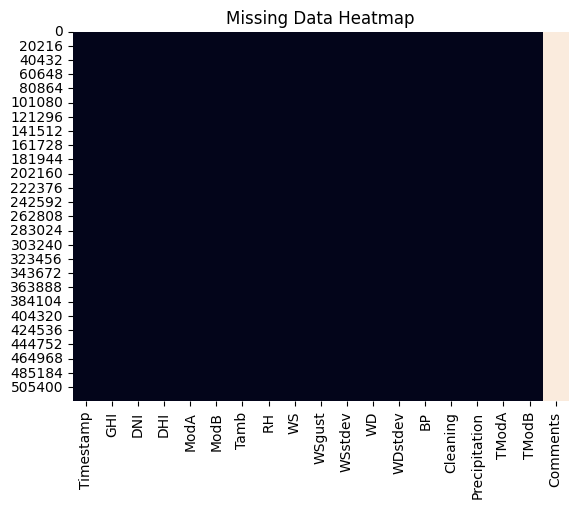

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Data Heatmap")
plt.show()


In [7]:
from scipy.stats import zscore

# Z-score for detecting outliers
z_scores = zscore(df[['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']])
outliers = (abs(z_scores) > 3)  # For example, flagging Z-score > 3 as outliers
print(outliers)


          GHI    DNI    DHI   ModA   ModB     WS  WSgust
0       False  False  False  False  False  False   False
1       False  False  False  False  False  False   False
2       False  False  False  False  False  False   False
3       False  False  False  False  False  False   False
4       False  False  False  False  False  False   False
...       ...    ...    ...    ...    ...    ...     ...
525595  False  False  False  False  False  False   False
525596  False  False  False  False  False  False   False
525597  False  False  False  False  False  False   False
525598  False  False  False  False  False  False   False
525599  False  False  False  False  False  False   False

[525600 rows x 7 columns]


# Time Series Analysis

In [8]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df.set_index('Timestamp', inplace=True)


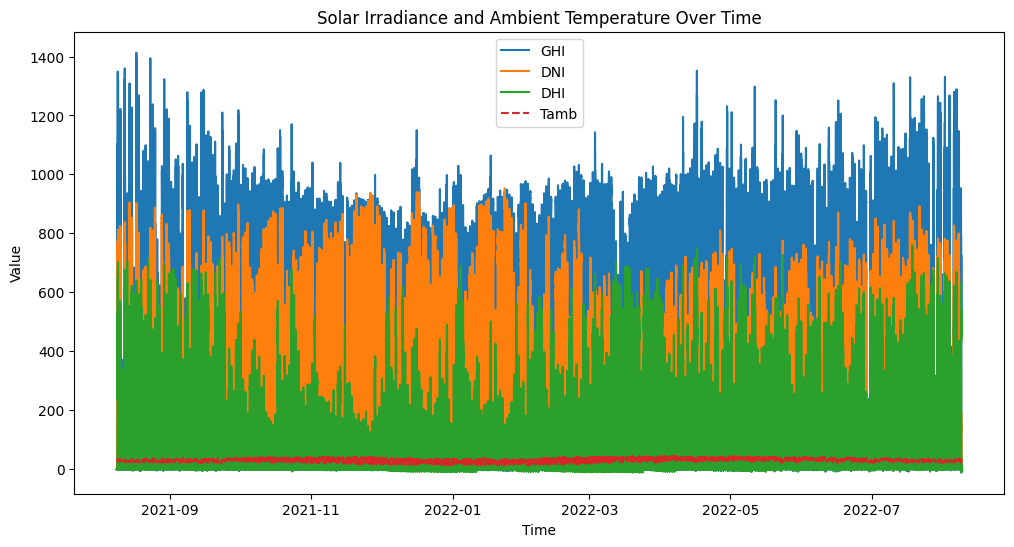

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['GHI'], label='GHI')
plt.plot(df.index, df['DNI'], label='DNI')
plt.plot(df.index, df['DHI'], label='DHI')
plt.plot(df.index, df['Tamb'], label='Tamb', linestyle='--')
plt.legend()
plt.title('Solar Irradiance and Ambient Temperature Over Time')
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()


## Check for anomalies in critical columns:

In [10]:
#Negative or zero values in solar radiation (GHI, DNI, DHI)
anomalies = df[(df['GHI'] < 0) | (df['DNI'] < 0) | (df['DHI'] < 0)] 
print('Negative or zero values in solar radiation (GHI, DNI, DHI)')
print(anomalies)
# Extreme values for wind speed (WS, WSgust)
outliers_ws = df[df['WS'] > df['WS'].quantile(0.99)]
print('Extreme values for wind speed (WS, WSgust)')
print(outliers_ws)
#Invalid entries for temperature (Tamb, TModA, TModB)
outliers_temp = df[(df['Tamb'] < -50) | (df['Tamb'] > 50)]  # Example thresholds
print('Invalid entries for temperature (Tamb, TModA, TModB)')
print(outliers_temp)

Negative or zero values in solar radiation (GHI, DNI, DHI)
                     GHI  DNI  DHI  ModA  ModB  Tamb    RH   WS  WSgust  \
Timestamp                                                                 
2021-08-09 00:01:00 -1.2 -0.2 -1.1   0.0   0.0  26.2  93.4  0.0     0.4   
2021-08-09 00:02:00 -1.1 -0.2 -1.1   0.0   0.0  26.2  93.6  0.0     0.0   
2021-08-09 00:03:00 -1.1 -0.2 -1.1   0.0   0.0  26.2  93.7  0.3     1.1   
2021-08-09 00:04:00 -1.1 -0.1 -1.0   0.0   0.0  26.2  93.3  0.2     0.7   
2021-08-09 00:05:00 -1.0 -0.1 -1.0   0.0   0.0  26.2  93.3  0.1     0.7   
...                  ...  ...  ...   ...   ...   ...   ...  ...     ...   
2022-08-08 23:56:00 -5.5 -0.1 -5.9   0.0   0.0  23.1  98.3  0.3     1.1   
2022-08-08 23:57:00 -5.5 -0.1 -5.8   0.0   0.0  23.1  98.3  0.2     0.7   
2022-08-08 23:58:00 -5.5 -0.1 -5.8   0.0   0.0  23.1  98.4  0.6     1.1   
2022-08-08 23:59:00 -5.5 -0.1 -5.8   0.0   0.0  23.1  98.3  0.9     1.3   
2022-08-09 00:00:00 -5.5 -0.1 -5.7   0.0 

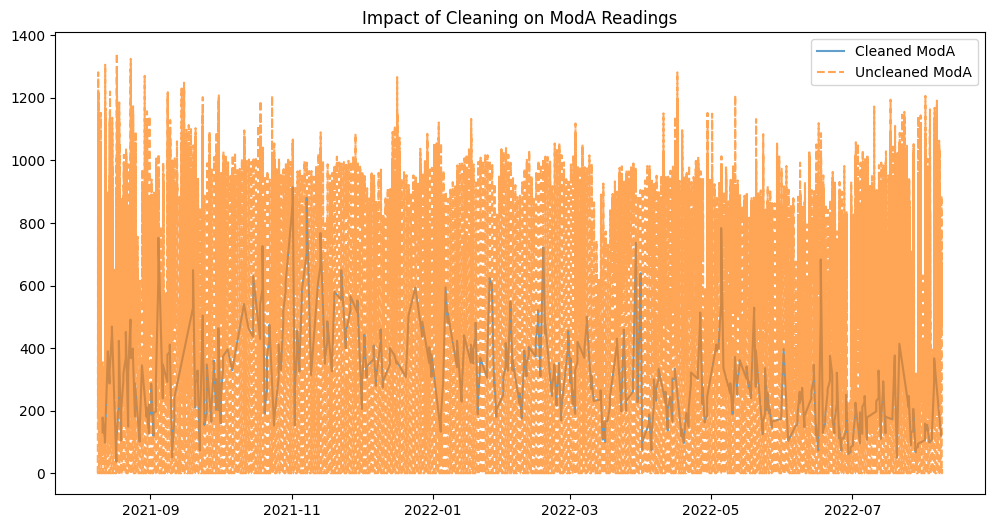

In [11]:
#Impact of Cleaning on sensor readings (ModA, ModB):
cleaned = df[df['Cleaning'] == 1]
uncleaned = df[df['Cleaning'] == 0]

plt.figure(figsize=(12, 6))
plt.plot(cleaned.index, cleaned['ModA'], label='Cleaned ModA', alpha=0.7)
plt.plot(uncleaned.index, uncleaned['ModA'], label='Uncleaned ModA', alpha=0.7, linestyle='dashed')
plt.legend()
plt.title('Impact of Cleaning on ModA Readings')
plt.show()

# Correlation Analysis


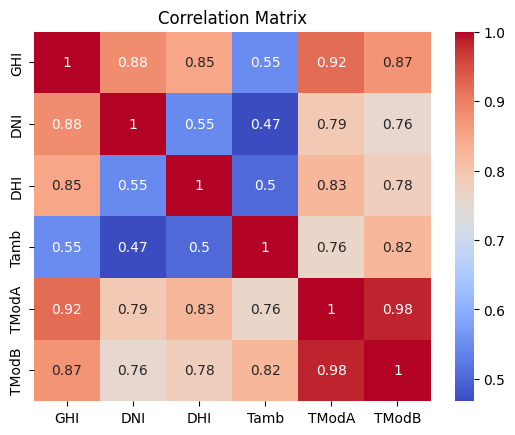

In [12]:
#Correlation between solar radiation and temperature
corr_matrix = df[['GHI', 'DNI', 'DHI', 'Tamb', 'TModA', 'TModB']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

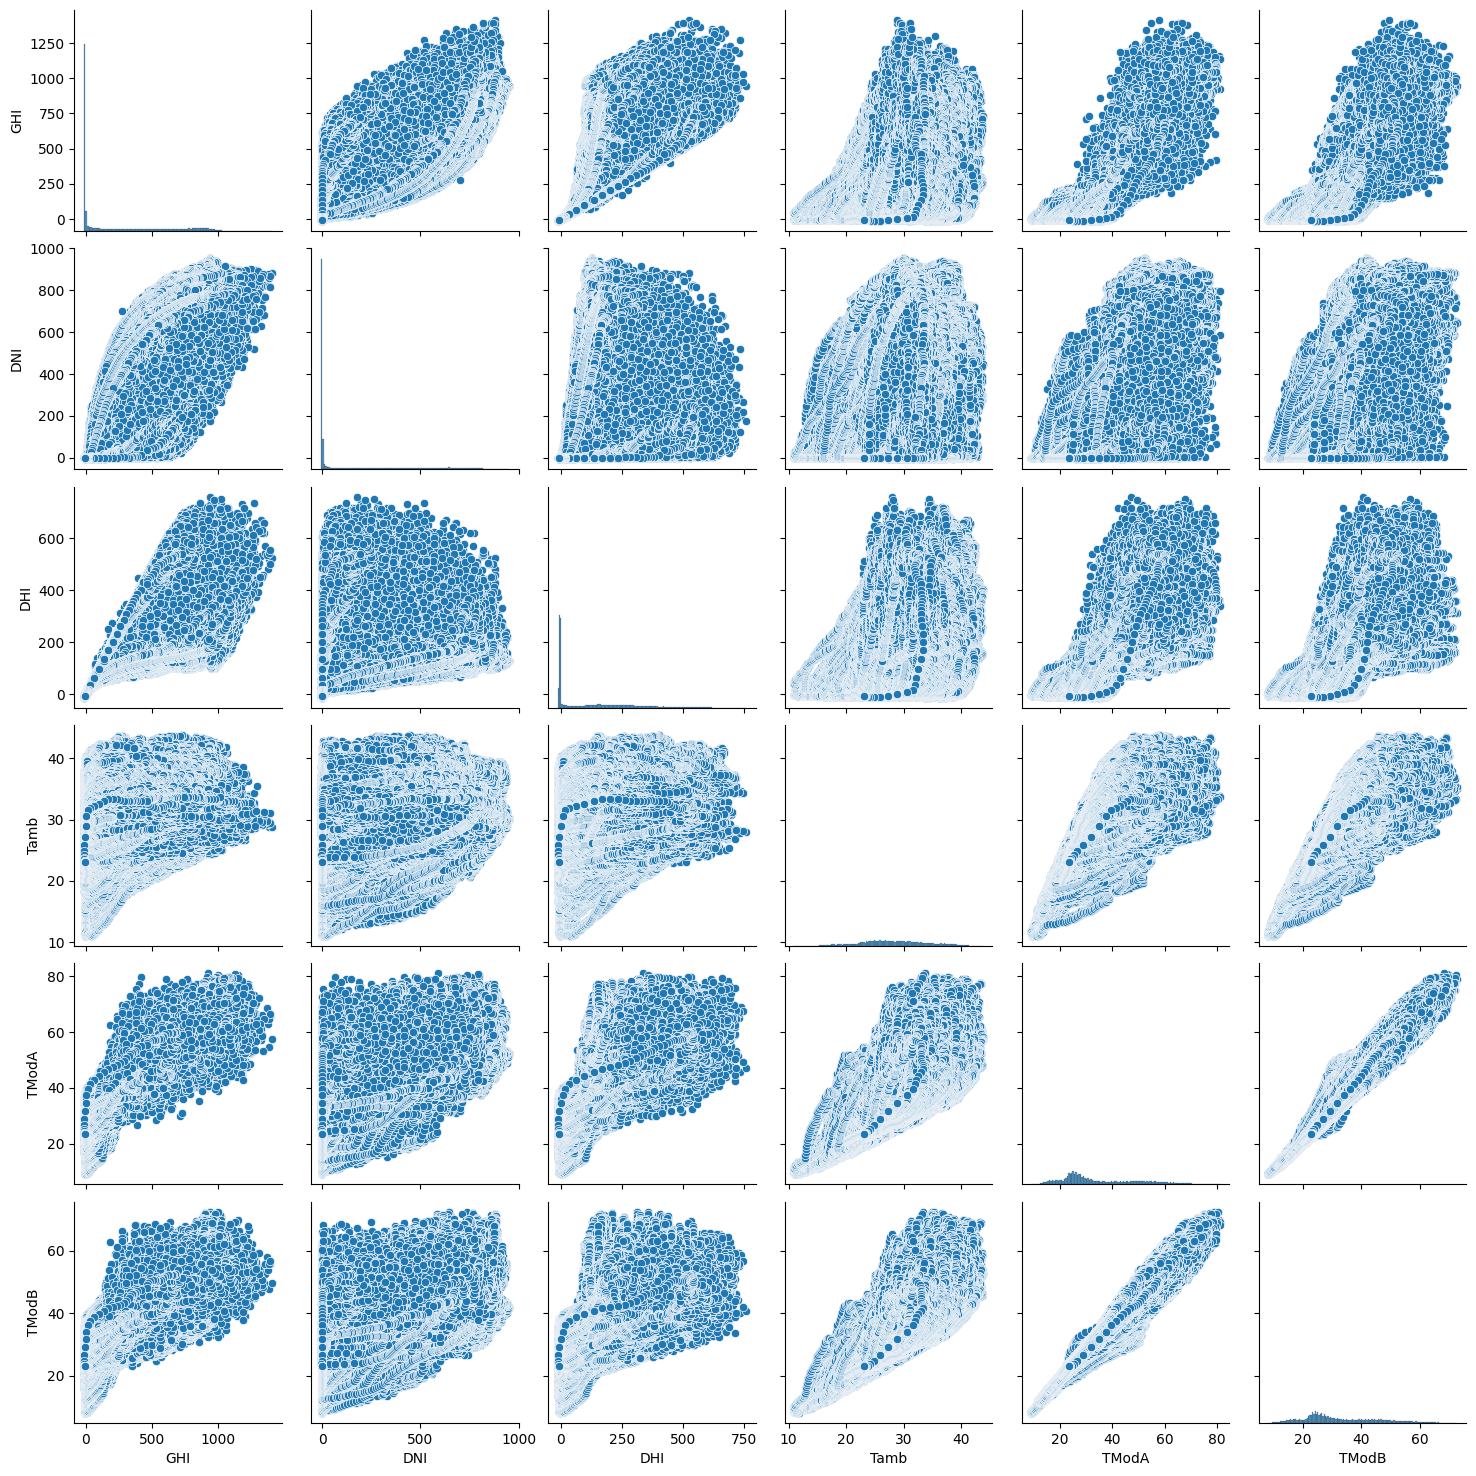

In [13]:
# Pair plot for solar and temperature variables:
sns.pairplot(df[['GHI', 'DNI', 'DHI', 'Tamb', 'TModA', 'TModB']])
plt.show()

# Wind Analysis

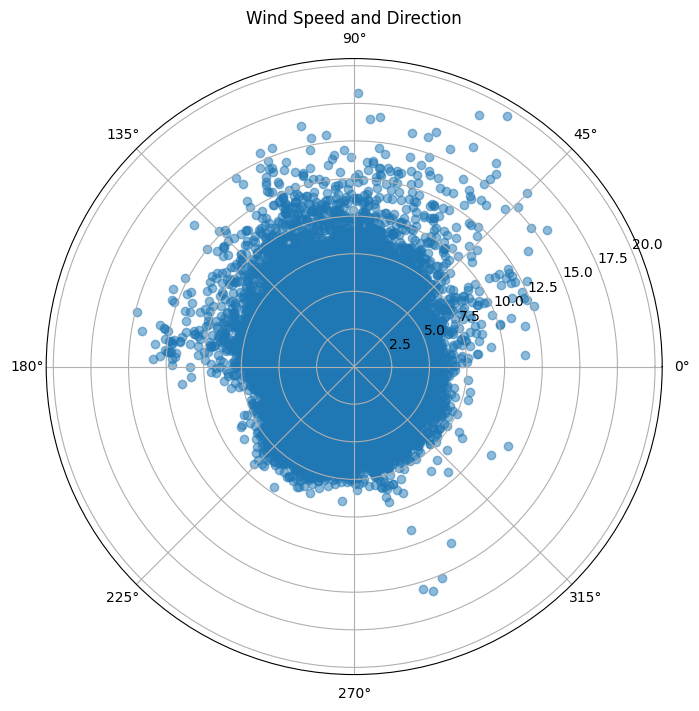

In [14]:
# Wind rose for WS and WD
import numpy as np

theta = np.radians(df['WD'])
r = df['WS']

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)
ax.scatter(theta, r, alpha=0.5)
ax.set_title('Wind Speed and Direction')
plt.show()


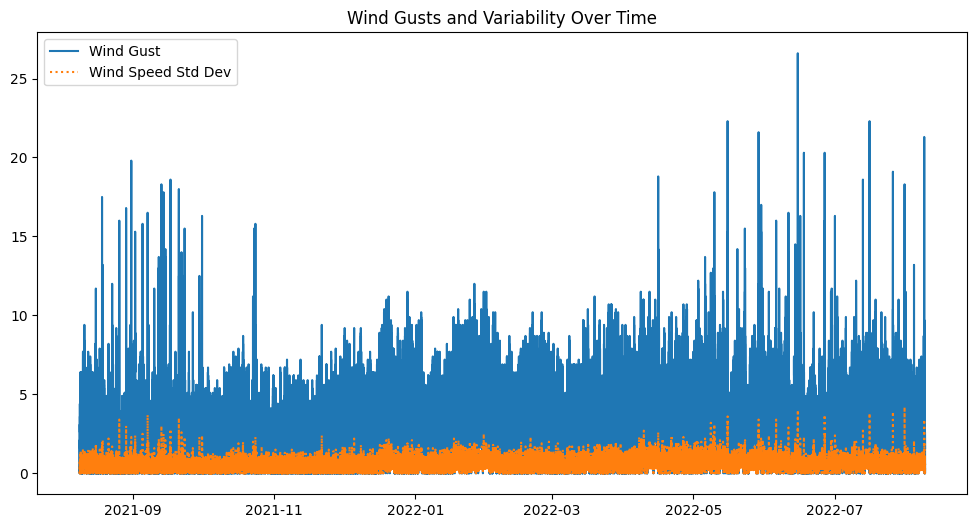

In [15]:
# Trends in wind gusts and variability:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['WSgust'], label='Wind Gust')
plt.plot(df.index, df['WSstdev'], label='Wind Speed Std Dev', linestyle='dotted')
plt.legend()
plt.title('Wind Gusts and Variability Over Time')
plt.show()


# Histograms

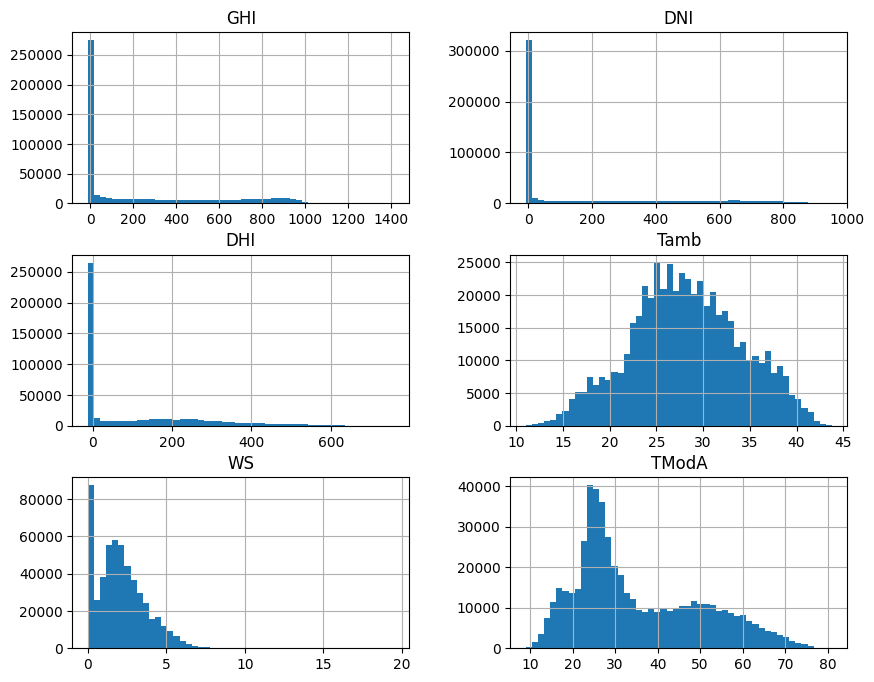

In [16]:
# Visualize frequency distribution
df[['GHI', 'DNI', 'DHI', 'Tamb', 'WS', 'TModA']].hist(bins=50, figsize=(10, 8))
plt.show()


# Z-Score Analysis

In [17]:
# Identify outliers based on Z-scores
from scipy.stats import zscore

z_scores = zscore(df[['GHI', 'DNI', 'DHI', 'ModA', 'ModB']])
outliers = (abs(z_scores) > 3)
print(outliers.sum())  # Number of flagged data points


GHI       89
DNI        0
DHI     3738
ModA      27
ModB      63
dtype: int64


# Data Cleaning

In [18]:
# Handle missing data
df = df.fillna(method='ffill')
# Remove invalid values
df = df[(df['GHI'] >= 0) & (df['DNI'] >= 0) & (df['DHI'] >= 0)]
# Drop unnecessary columns
df = df.drop(columns=['Comments'])  # If mostly null

/tmp/ipykernel_60729/4020175998.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [19]:
df.to_csv(f'../data/processed/proecssed_{fileName}', index=False)
